# Stress test — Actual · Óptima · Bajo protocolo

**Pregunta:** ante demanda incierta, ¿cuánto se **rompe** cada portafolio (nivel de costo y desvío)?

| Portafolio | Origen |
|------------|--------|
| **Actual** | Baseline histórico |
| **Óptima** | Mark 16 (ve demanda) |
| **Bajo protocolo** | Mark 17 (demand-free) |

Métrica: **costo total Kaggle**. Asignaciones fijas; solo cambia la demanda.

1. **Uniforme** — sanity check de nivel/gap  
2. **Monte Carlo** — costo medio + desvío (estabilidad)

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "operaciones_planta.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

from evaluate import (
    SUBMISSION_COLS,
    PRECIO_BASE_GROSOR_FULL,
    costo_flete_eval,
    factor_precio_por_volumen,
    preparar_eval_planta,
)
from mark16 import costo_actual_oficial, score_publico
from settings import PLANTAS

GREEN = "#5CAC31"
GRAY = "#706F6F"
GREEN_DARK = "#3B7434"
LIGHT_GRAY = "#DADADA"
BG = "#FFFFFF"

ACT = "Actual"
OPT = "Best"
IND = "Mark17"
SHORT = {ACT: "Actual", OPT: "Óptima", IND: "Bajo protocolo"}
FULL = dict(SHORT)
COLORS = {ACT: GRAY, OPT: GREEN, IND: GREEN_DARK}
ORDER = (ACT, OPT, IND)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": LIGHT_GRAY,
    "axes.labelcolor": GRAY,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "text.color": GRAY,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "legend.frameon": False,
})


def style_ax(ax, title: str, subtitle: str | None = None):
    ax.set_facecolor(BG)
    ax.spines["bottom"].set_color(LIGHT_GRAY)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(length=0, colors=GRAY, labelsize=9)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.8)
    ax.set_axisbelow(True)
    y_title = 1.16 if subtitle else 1.06
    ax.text(
        0.0, y_title, title, transform=ax.transAxes,
        fontsize=12, fontweight="bold", color=GREEN_DARK,
        va="bottom", ha="left", clip_on=False,
    )
    if subtitle:
        ax.text(
            0.0, 1.06, subtitle, transform=ax.transAxes,
            fontsize=9, color=GRAY, va="bottom", ha="left", clip_on=False,
        )


def finish_fig(fig):
    fig.patch.set_facecolor(BG)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    fig.subplots_adjust(top=0.80, wspace=0.30)
    plt.show()


def evaluar_kaggle(sol: pd.DataFrame, ops_df: pd.DataFrame) -> dict:
    df = preparar_eval_planta(sol[SUBMISSION_COLS], ops_df)
    precio_base = (
        df.groupby("tipo")["caja_grosor_mm"].first().round(1).map(PRECIO_BASE_GROSOR_FULL)
    )
    if precio_base.isna().any():
        raise ValueError("Grosores sin precio base")
    pack = 0.0
    for planta in PLANTAS:
        vol_tp = df.groupby("tipo")[f"volumen_producto_planta_{planta}"].sum()
        factor = factor_precio_por_volumen(vol_tp)
        pack += float((vol_tp.values * precio_base.loc[vol_tp.index].values * factor).sum())
    flete = float(costo_flete_eval(df))
    return {"total": pack + flete, "packaging": pack, "flete": flete}


ops = pd.read_csv(ROOT / "data/raw/operaciones_planta.csv")
ops["codigo_producto"] = ops["codigo_producto"].astype(str).str.strip()
TABLES = ROOT / "outputs" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

actual = pd.read_csv(TABLES / "00_baseline_solution.csv")[SUBMISSION_COLS].copy()
optima = pd.read_csv(TABLES / "04_mark16_best_+10.11098.csv")[SUBMISSION_COLS].copy()
indep = pd.read_csv(ROOT / "outputs/mark17/mark17_from_minbox.csv")[SUBMISSION_COLS].copy()
for df in (actual, optima, indep):
    df["codigo_producto"] = df["codigo_producto"].astype(str).str.strip()

SOLS = {ACT: actual, OPT: optima, IND: indep}
COSTO_OFICIAL_0 = costo_actual_oficial(ops)
VOL_COLS = ["volumen_producto_total", *[f"volumen_producto_planta_{p}" for p in PLANTAS]]
SHOCKS = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

ev0 = {name: evaluar_kaggle(sol, ops) for name, sol in SOLS.items()}
print(f"ROOT = {ROOT}")
print(f"Baseline oficial: USD {COSTO_OFICIAL_0:,.2f}")
for name in ORDER:
    tot = ev0[name]["total"]
    print(
        f"  {FULL[name]:16s}  ${tot:,.0f}  "
        f"score={score_publico(tot, COSTO_OFICIAL_0):+.5f}"
    )
assert abs(score_publico(ev0[OPT]["total"], COSTO_OFICIAL_0) - 10.11098) < 1e-4
print(
    f"Gap Bajo protocolo−Óptima @0%: USD {ev0[IND]['total'] - ev0[OPT]['total']:,.0f}"
)

ROOT = /home/lorenn/Desktop/Universidad/Competencia-AlixPartners
Baseline oficial: USD 209,235,093.94
  Actual            $209,364,272  score=-0.06174
  Óptima            $188,079,384  score=+10.11098
  Bajo protocolo    $189,197,949  score=+9.57638
Gap Bajo protocolo−Óptima @0%: USD 1,118,565


## 1. Shocks uniformes — nivel de costo

Sanity check: misma escala para todos los SKUs. Sirve para ver el **gap de nivel**, no la estabilidad
(con pocos puntos determinísticos el desvío no interpreta bien).

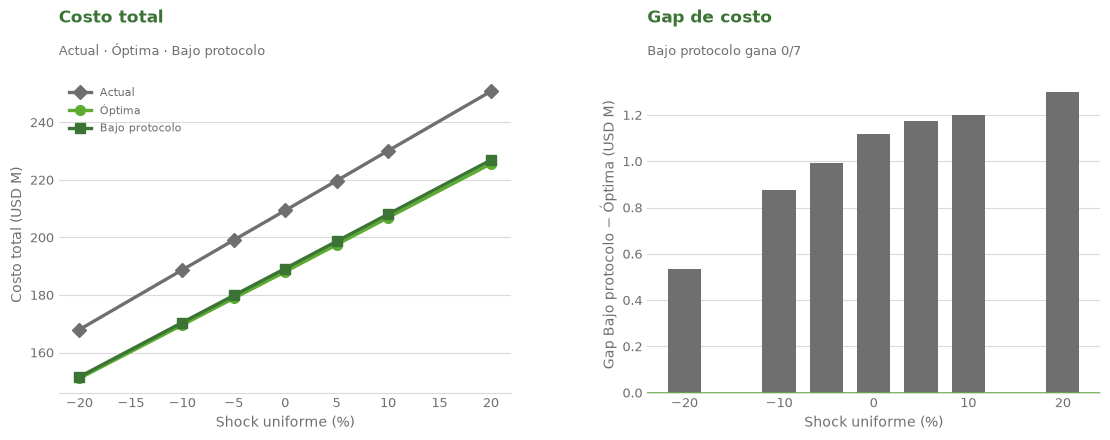

shock_pct,costo_actual,costo_optima,costo_bajo_protocolo,gap_proto_minus_optima,gana
-20%,"$167,983,069","$151,031,567","$151,564,457","$532,889",Óptima
-10%,"$188,715,702","$169,574,505","$170,449,921","$875,416",Óptima
-5%,"$199,071,813","$178,843,085","$179,835,568","$992,483",Óptima
+0%,"$209,364,272","$188,079,384","$189,197,949","$1,118,565",Óptima
+5%,"$219,704,083","$197,478,484","$198,651,308","$1,172,825",Óptima
+10%,"$230,104,414","$206,871,734","$208,071,974","$1,200,241",Óptima
+20%,"$250,759,704","$225,596,617","$226,895,887","$1,299,270",Óptima


In [2]:
def shock_ops(ops_df: pd.DataFrame, shock: float) -> pd.DataFrame:
    out = ops_df.copy()
    out[VOL_COLS] = out[VOL_COLS].astype(float) * (1.0 + float(shock))
    return out


MARKERS = {ACT: "D-", OPT: "o-", IND: "s-"}
rows = []
for shock in SHOCKS:
    ops_s = shock_ops(ops, shock)
    c_act = evaluar_kaggle(actual, ops_s)["total"]
    c_opt = evaluar_kaggle(optima, ops_s)["total"]
    c_ind = evaluar_kaggle(indep, ops_s)["total"]
    rows.append(
        {
            "shock_pct": 100.0 * shock,
            "costo_actual": c_act,
            "costo_optima": c_opt,
            "costo_bajo_protocolo": c_ind,
            "gap_proto_minus_optima": c_ind - c_opt,
            "gana": SHORT[IND] if c_ind < c_opt else SHORT[OPT],
        }
    )
uniform = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

ax = axes[0]
for name, col in [
    (ACT, "costo_actual"),
    (OPT, "costo_optima"),
    (IND, "costo_bajo_protocolo"),
]:
    ax.plot(
        uniform["shock_pct"], uniform[col] / 1e6, MARKERS[name],
        color=COLORS[name], lw=2.4, ms=7, label=SHORT[name],
    )
ax.set_xlabel("Shock uniforme (%)")
ax.set_ylabel("Costo total (USD M)")
style_ax(ax, "Costo total", "Actual · Óptima · Bajo protocolo")
ax.legend(fontsize=8)

ax = axes[1]
gap = uniform["gap_proto_minus_optima"]
ax.bar(uniform["shock_pct"], gap / 1e6, width=3.5, color=[GREEN_DARK if g < 0 else GRAY for g in gap])
ax.axhline(0, color=GREEN, lw=1.2)
ax.set_xlabel("Shock uniforme (%)")
ax.set_ylabel("Gap Bajo protocolo − Óptima (USD M)")
n_win = int((gap < 0).sum())
style_ax(ax, "Gap de costo", f"Bajo protocolo gana {n_win}/{len(uniform)}")
finish_fig(fig)

display(
    uniform.style.format({
        "shock_pct": "{:+.0f}%",
        "costo_actual": "${:,.0f}",
        "costo_optima": "${:,.0f}",
        "costo_bajo_protocolo": "${:,.0f}",
        "gap_proto_minus_optima": "${:,.0f}",
    }).hide(axis="index")
)

## 2. Monte Carlo — costo total y desvío

N=1000, σ=10% por SKU×planta. Misma demanda en ambas.

- **Costo medio** → qué tan cara es la solución  
- **Desvío (std / CV)** → qué tanto se **rompe** cuando la demanda tiembla  

Menor CV = más estable ante el mismo ruido.

  200/1000…


  400/1000…


  600/1000…


  800/1000…


  1000/1000…


Listo en 71.2s | N=1000 σ=10%
Bajo protocolo gana en 0.0% de las sims
Más estable (menor CV): Actual
std Bajo protocolo / std Óptima = 1.005


Portafolio,Media,Std,CV,P5,P95,Rango P5–P95
Actual,"$209,489,126","$2,125,125",1.014%,"$206,015,220","$212,972,427","$6,957,207"
Óptima,"$188,253,792","$1,937,756",1.029%,"$185,014,474","$191,472,856","$6,458,381"
Bajo protocolo,"$189,333,230","$1,948,212",1.029%,"$186,084,954","$192,566,806","$6,481,851"


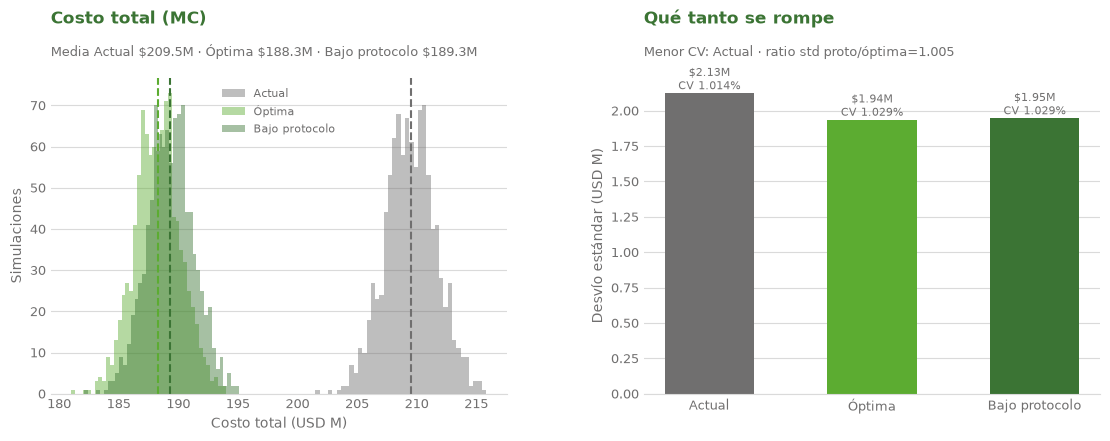

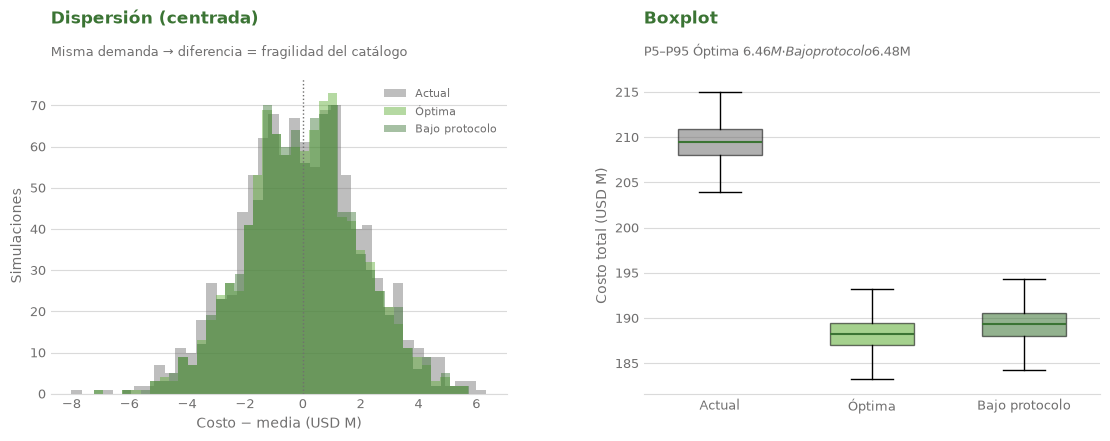

In [3]:
N_SIM = 1000
SIGMA = 0.10
RNG = np.random.default_rng(42)
plant_cols = [f"volumen_producto_planta_{p}" for p in PLANTAS]
n_sku, n_pl = len(ops), len(PLANTAS)


def apply_eps_matrix(ops_df: pd.DataFrame, eps: np.ndarray) -> pd.DataFrame:
    out = ops_df.copy()
    for j, col in enumerate(plant_cols):
        vol = out[col].to_numpy(float)
        out[col] = np.maximum(0.0, vol * (1.0 + eps[:, j]))
    out["volumen_producto_total"] = sum(out[c] for c in plant_cols)
    return out


costs = {name: np.empty(N_SIM) for name in ORDER}

t0 = __import__("time").time()
for s in range(N_SIM):
    eps = RNG.normal(0.0, SIGMA, size=(n_sku, n_pl))
    ops_s = apply_eps_matrix(ops, eps)
    for name, sol in SOLS.items():
        costs[name][s] = evaluar_kaggle(sol, ops_s)["total"]
    if (s + 1) % 200 == 0:
        print(f"  {s+1}/{N_SIM}…", flush=True)
elapsed = __import__("time").time() - t0

cost_act, cost_opt, cost_ind = costs[ACT], costs[OPT], costs[IND]
gap_mc = cost_ind - cost_opt
mc = pd.DataFrame({
    "sim": np.arange(N_SIM),
    "costo_actual": cost_act,
    "costo_optima": cost_opt,
    "costo_bajo_protocolo": cost_ind,
    "gap_proto_minus_optima": gap_mc,
    "proto_gana": gap_mc < 0,
})

print(f"Listo en {elapsed:.1f}s | N={N_SIM} σ={SIGMA:.0%}")
print(f"Bajo protocolo gana en {(gap_mc < 0).mean()*100:.1f}% de las sims")


def stats_costo(arr: np.ndarray, label: str) -> dict:
    return {
        "Portafolio": label,
        "media": float(arr.mean()),
        "std": float(arr.std(ddof=1)),
        "cv_pct": float(100.0 * arr.std(ddof=1) / arr.mean()),
        "p5": float(np.percentile(arr, 5)),
        "p95": float(np.percentile(arr, 95)),
        "rango_p5_p95": float(np.percentile(arr, 95) - np.percentile(arr, 5)),
    }


stab = pd.DataFrame([stats_costo(costs[n], FULL[n]) for n in ORDER])
idx = {FULL[n]: i for i, n in enumerate(ORDER)}
mas_estable = stab.loc[stab["cv_pct"].idxmin(), "Portafolio"]
ratio_std = stab.loc[idx[FULL[IND]], "std"] / stab.loc[idx[FULL[OPT]], "std"]

print(f"Más estable (menor CV): {mas_estable}")
print(f"std Bajo protocolo / std Óptima = {ratio_std:.3f}")


def fmt_money(x: float) -> str:
    return f"${x:,.0f}"


def fmt_cv(x: float) -> str:
    return f"{x:.3f}%"


css = f"""
.st-wrap {{
  background: #fff; color: {GRAY}; padding: 8px 4px 16px;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif;
  overflow-x: auto;
}}
.st-title {{
  color: {GREEN_DARK}; font-weight: 700; font-size: 14px; margin: 0 0 4px 4px;
}}
.st-sub {{
  color: {GRAY}; font-size: 11px; margin: 0 0 14px 4px;
}}
.st-table {{
  width: 100%; border-collapse: collapse; font-size: 13px; background: #fff;
}}
.st-table th {{
  text-align: left; font-weight: 500; font-size: 11px; letter-spacing: 0.04em;
  text-transform: uppercase; color: {GRAY}; padding: 10px 12px;
  border-bottom: 1px solid {LIGHT_GRAY}; background: #fff; white-space: nowrap;
}}
.st-table th.num, .st-table td.num {{
  text-align: right; font-variant-numeric: tabular-nums;
}}
.st-table td {{
  padding: 12px 12px; color: {GRAY}; border: none; background: #fff; vertical-align: middle;
}}
.st-table tr + tr td {{ border-top: 1px solid {LIGHT_GRAY}; }}
.st-table td.solucion {{
  font-weight: 600; color: {GREEN_DARK}; text-align: left; white-space: nowrap;
}}
"""

body = []
for _, r in stab.iterrows():
    body.append(
        "<tr>"
        f'<td class="solucion">{r["Portafolio"]}</td>'
        f'<td class="num">{fmt_money(float(r["media"]))}</td>'
        f'<td class="num">{fmt_money(float(r["std"]))}</td>'
        f'<td class="num">{fmt_cv(float(r["cv_pct"]))}</td>'
        f'<td class="num">{fmt_money(float(r["p5"]))}</td>'
        f'<td class="num">{fmt_money(float(r["p95"]))}</td>'
        f'<td class="num">{fmt_money(float(r["rango_p5_p95"]))}</td>'
        "</tr>"
    )

html = f"""
<style>{css}</style>
<div class="st-wrap">
  <p class="st-title">Estabilidad Monte Carlo</p>
  <p class="st-sub">N={N_SIM} · σ={SIGMA:.0%} · menor CV = más estable ante el mismo ruido.</p>
  <table class="st-table">
    <thead>
      <tr>
        <th>Portafolio</th>
        <th class="num">Media</th>
        <th class="num">Std</th>
        <th class="num">CV</th>
        <th class="num">P5</th>
        <th class="num">P95</th>
        <th class="num">Rango P5–P95</th>
      </tr>
    </thead>
    <tbody>
      {"".join(body)}
    </tbody>
  </table>
</div>
"""
display(HTML(html))

# --- Gráficos: costo + desvío ---
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

ax = axes[0]
for name in ORDER:
    ax.hist(costs[name] / 1e6, bins=40, alpha=0.45, color=COLORS[name], label=SHORT[name])
    ax.axvline(costs[name].mean() / 1e6, color=COLORS[name], lw=1.5, ls="--")
ax.set_xlabel("Costo total (USD M)")
ax.set_ylabel("Simulaciones")
m_act = stab.loc[idx[FULL[ACT]], "media"] / 1e6
m_opt = stab.loc[idx[FULL[OPT]], "media"] / 1e6
m_ind = stab.loc[idx[FULL[IND]], "media"] / 1e6
style_ax(
    ax,
    "Costo total (MC)",
    f"Media Actual ${m_act:.1f}M · Óptima ${m_opt:.1f}M · Bajo protocolo ${m_ind:.1f}M",
)
ax.legend(fontsize=8)

ax = axes[1]
labels_bar = [SHORT[n] for n in ORDER]
stds = [stab.loc[idx[FULL[n]], "std"] / 1e6 for n in ORDER]
cvs = [stab.loc[idx[FULL[n]], "cv_pct"] for n in ORDER]
x = np.arange(len(ORDER))
bars = ax.bar(x, stds, color=[COLORS[n] for n in ORDER], width=0.55)
for i, (bar, cv) in enumerate(zip(bars, cvs)):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"${stds[i]:.2f}M\nCV {cv:.3f}%",
        ha="center", va="bottom", fontsize=8, color=GRAY,
    )
ax.set_xticks(x)
ax.set_xticklabels(labels_bar)
ax.set_ylabel("Desvío estándar (USD M)")
style_ax(ax, "Qué tanto se rompe", f"Menor CV: {mas_estable} · ratio std proto/óptima={ratio_std:.3f}")
finish_fig(fig)

# Dispersión centrada + boxplot
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

ax = axes[0]
for name in ORDER:
    arr = costs[name]
    ax.hist((arr - arr.mean()) / 1e6, bins=40, alpha=0.45, color=COLORS[name], label=SHORT[name])
ax.axvline(0, color=GRAY, lw=1.0, ls=":")
ax.set_xlabel("Costo − media (USD M)")
ax.set_ylabel("Simulaciones")
style_ax(ax, "Dispersión (centrada)", "Misma demanda → diferencia = fragilidad del catálogo")
ax.legend(fontsize=8)

ax = axes[1]
bp = ax.boxplot(
    [costs[n] / 1e6 for n in ORDER],
    tick_labels=[SHORT[n] for n in ORDER],
    patch_artist=True, widths=0.55, showfliers=False,
)
for patch, name in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.55)
for med in bp["medians"]:
    med.set_color(GREEN_DARK)
    med.set_linewidth(1.5)
r_opt = stab.loc[idx[FULL[OPT]], "rango_p5_p95"] / 1e6
r_ind = stab.loc[idx[FULL[IND]], "rango_p5_p95"] / 1e6
ax.set_ylabel("Costo total (USD M)")
style_ax(ax, "Boxplot", f"P5–P95 Óptima ${r_opt:.2f}M · Bajo protocolo ${r_ind:.2f}M")
finish_fig(fig)

## 3. Lectura

Nivel (quién es más barata) vs desvío (quién se rompe más) entre Actual, Óptima y Bajo protocolo.

In [4]:
uni_wins = int((uniform["gap_proto_minus_optima"] < 0).sum())
mc_wins = int(mc["proto_gana"].sum())
gap0 = float(uniform.loc[uniform.shock_pct == 0, "gap_proto_minus_optima"].iloc[0])
std_opt = stab.loc[idx[FULL[OPT]], "std"]
std_ind = stab.loc[idx[FULL[IND]], "std"]
cv_opt = stab.loc[idx[FULL[OPT]], "cv_pct"]
cv_ind = stab.loc[idx[FULL[IND]], "cv_pct"]
cv_act = stab.loc[idx[FULL[ACT]], "cv_pct"]

lines = [
    f"- **Nivel @0%:** gap Bajo protocolo−Óptima = **${gap0:,.0f}** (Óptima más barata).",
    f"- **Uniforme:** Bajo protocolo gana en **{uni_wins}/{len(uniform)}** shocks.",
    f"- **MC nivel:** Bajo protocolo gana en **{mc_wins}/{N_SIM}** sims; gap medio **${gap_mc.mean():,.0f}**.",
    f"- **MC desvío:** std Óptima **${std_opt:,.0f}** · Bajo protocolo **${std_ind:,.0f}** "
    f"(ratio {ratio_std:.3f}). CV Actual **{cv_act:.3f}%** · Óptima **{cv_opt:.3f}%** · "
    f"Bajo protocolo **{cv_ind:.3f}%**.",
    f"- **Más estable:** **{mas_estable}**.",
]

if abs(ratio_std - 1.0) < 0.02 and mc_wins == 0:
    verdict = (
        "**Veredicto:** Bajo protocolo **no gana en nivel** (~USD 1.1 M más cara) y en desvío **empatan** "
        "(ratio std ≈ 1). No se rompe más por no haber visto demanda; el trade-off es solo de costo medio."
    )
elif ratio_std < 0.98:
    verdict = "**Veredicto:** Bajo protocolo se rompe **menos** (menor desvío) pese a ser algo más cara."
elif ratio_std > 1.02:
    verdict = "**Veredicto:** Bajo protocolo se rompe **más** ante el mismo ruido de demanda."
else:
    verdict = "**Veredicto:** estabilidad similar; la diferencia relevante es el nivel de costo."

display(Markdown("\n".join(lines + ["", verdict])))

out_u = TABLES / "180_optima_vs_indep_uniform.csv"
out_mc = TABLES / "180_optima_vs_indep_mc.csv"
out_stab = TABLES / "180_optima_vs_indep_mc_stability.csv"
uniform.to_csv(out_u, index=False)
mc.to_csv(out_mc, index=False)
stab.to_csv(out_stab, index=False)
print("CSV:", out_u.name, out_mc.name, out_stab.name)

- **Nivel @0%:** gap Bajo protocolo−Óptima = **$1,118,565** (Óptima más barata).
- **Uniforme:** Bajo protocolo gana en **0/7** shocks.
- **MC nivel:** Bajo protocolo gana en **0/1000** sims; gap medio **$1,079,438**.
- **MC desvío:** std Óptima **$1,937,756** · Bajo protocolo **$1,948,212** (ratio 1.005). CV Actual **1.014%** · Óptima **1.029%** · Bajo protocolo **1.029%**.
- **Más estable:** **Actual**.

**Veredicto:** Bajo protocolo **no gana en nivel** (~USD 1.1 M más cara) y en desvío **empatan** (ratio std ≈ 1). No se rompe más por no haber visto demanda; el trade-off es solo de costo medio.

CSV: 180_optima_vs_indep_uniform.csv 180_optima_vs_indep_mc.csv 180_optima_vs_indep_mc_stability.csv
